In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CORE HELPER FUNCTIONS
# ==============================================================================

def calculate_polygon_area(x, y):
    """
    Calculates the area of a polygon using the Shoelace formula.
    REQUIRES: The last point must close the polygon (same as first point).
    """
    x = np.array(x)
    y = np.array(y)

    # SANITY: Polygon must have at least 3 unique vertices + 1 closing point
    assert len(x) >= 4, f"Polygon must have >= 4 points (3 vertices + closing). Got {len(x)}."
    assert len(x) == len(y), f"x and y must have equal length. Got x={len(x)}, y={len(y)}."
    assert np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1]), \
        f"Last point {(x[-1], y[-1])} must close polygon at {(x[0], y[0])}."

    # Shoelace: sum(x[i]*y[i+1] - x[i+1]*y[i]) over all edges
    area = 0.5 * np.abs(np.dot(x[:-1], y[1:]) - np.dot(x[1:], y[:-1]))

    # SANITY: Area must be positive for a non-degenerate polygon
    assert area > 1e-9, f"Polygon area is near-zero ({area:.6f}). Check for collinear/duplicate vertices."
    return area


def expand_from_6dim_to_xy(x1, y1, theta1, theta2, theta3, theta4, vehicle_geometrics):
    """
    Calculates the exact XY coordinates of all trailer axles based on the
    tractor rear-axle position (x1, y1) and all heading angles.

    For an off-axle hitch (M > 0):
      - The hitch point on unit i is M[i] BEHIND its rear axle.
      - Trailer i+1's rear axle is L[i+1] BEHIND the hitch point, along theta_{i+1}.

    For on-axle hitch (M == 0): reduces to standard on-axle model.

    RETURNS: (x2, y2, x3, y3, x4, y4) — rear-axle positions of trailers 1, 2, 3.
    """
    L = vehicle_geometrics['L']  # [tractor_wb, trailer1_wb, trailer2_wb, trailer3_wb]
    M = vehicle_geometrics['M']  # [hitch_offset_0, hitch_offset_1, hitch_offset_2, hitch_offset_3]

    # SANITY: Check geometry arrays
    assert len(L) >= 4, f"L must have at least 4 elements. Got {len(L)}."
    assert len(M) >= 3, f"M must have at least 3 elements. Got {len(M)}."
    assert all(l > 0 for l in L), f"All wheelbase lengths L must be positive. Got {L}."
    assert all(m >= 0 for m in M), f"All hitch offsets M must be non-negative. Got {M}."

    # Trailer 1 rear axle:
    #   Start from tractor rear axle (x1,y1),
    #   go M[0] backward along tractor heading theta1 to reach hitch point,
    #   then go L[1] backward along trailer1 heading theta2.
    x2 = x1 - M[0] * np.cos(theta1) - L[1] * np.cos(theta2)
    y2 = y1 - M[0] * np.sin(theta1) - L[1] * np.sin(theta2)

    # Trailer 2 rear axle
    x3 = x2 - M[1] * np.cos(theta2) - L[2] * np.cos(theta3)
    y3 = y2 - M[1] * np.sin(theta2) - L[2] * np.sin(theta3)

    # Trailer 3 rear axle
    x4 = x3 - M[2] * np.cos(theta3) - L[3] * np.cos(theta4)
    y4 = y3 - M[2] * np.sin(theta3) - L[3] * np.sin(theta4)

    return np.array(x2), np.array(y2), np.array(x3), np.array(y3), np.array(x4), np.array(y4)




def setup_environment(test_case_number=3.2):
    """Initializes all vehicle parameters, limits, and boundary conditions."""

    # SANITY: Valid test cases are x.1 or x.2 where x ∈ {1, 2, 3}
    valid_cases = {1.1, 1.2, 2.1, 2.2, 3.1, 3.2}
    assert test_case_number in valid_cases, \
        f"Invalid test_case_number {test_case_number}. Must be one of {valid_cases}."

    case_id = round(test_case_number)
    off_axle_flag = 1 if round(test_case_number * 10) % 10 == 2 else 0

    print(f"[INIT] Test Case: {test_case_number} | Case ID: {case_id} | Off-axle hitch: {'YES' if off_axle_flag else 'NO'}")

    # 1. Planning Scale
    planning_scale = {
        'xmin': -30.0, 'xmax': 20.0,
        'ymin': -20.0, 'ymax': 20.0,
        'xhorizon': 50.0, 'yhorizon': 40.0
    }
    assert planning_scale['xhorizon'] == planning_scale['xmax'] - planning_scale['xmin'], \
        "xhorizon must equal xmax - xmin."
    assert planning_scale['yhorizon'] == planning_scale['ymax'] - planning_scale['ymin'], \
        "yhorizon must equal ymax - ymin."

    # 2. Vehicle Geometrics
    vehicle_geometrics = {
        'L_tractor_front_hang': 0.25,
        'L_tractor_wheelbase': 1.5,
        'L_tractor_rear_hang': 0.25,
        'LHW': 1.0,                                                # Half-width
        'M': np.array([1.5, 1.5, 1.5, 1.5]) * off_axle_flag,     # Hitch offsets
        'L': np.array([3.0, 3.0, 3.0, 3.0]),                      # Wheelbases
        'L_trailer_front_hang': 1.0,
        'L_trailer_rear_hang': 1.0
    }

    # SANITY: Physical geometry checks
    assert vehicle_geometrics['L_tractor_wheelbase'] > 0, "Tractor wheelbase must be positive."
    assert vehicle_geometrics['LHW'] > 0, "Half-width must be positive."
    assert all(vehicle_geometrics['L'] > 0), "All trailer wheelbases must be positive."

    # 3. Vehicle Physics (Limits)
    vehicle_physics = {
        'v_max': 1.5,
        'phy_max': 0.7,    # Max steering angle (rad) ≈ 40 degrees
        'a_max': 0.25,
        'w_max': 0.5,
    }
    vehicle_physics['min_turning_radius'] = (
        vehicle_geometrics['L_tractor_wheelbase'] / np.tan(vehicle_physics['phy_max'])
    )

    # SANITY: Physical limits
    assert 0 < vehicle_physics['phy_max'] < np.pi / 2, \
        f"Steering limit phy_max={vehicle_physics['phy_max']:.3f} must be in (0, pi/2)."
    print(f"[INIT] Min turning radius: {vehicle_physics['min_turning_radius']:.3f} m")

    # 4. Hybrid A* Parameters
    hybrid_astar = {
        'resolution_x': 0.15, 'resolution_y': 0.15, 'resolution_theta': 0.2,
        'penalty_multiplier_for_reversing': 3.0,
        'penalty_multiplier_for_drastic_direction_change': 5.0,
        'multiplier_H': 3.0,
        'num_iters_for_rs': 10,
        'max_iter': 30000,
        'terminal_xy_neiborhood': 5.0,
        'terminal_theta_neiborhood': 1.0
    }
    hybrid_astar['num_nodes_x'] = (
        int(np.ceil(planning_scale['xhorizon'] / hybrid_astar['resolution_x'])) + 1
    )
    hybrid_astar['num_nodes_y'] = (
        int(np.ceil(planning_scale['yhorizon'] / hybrid_astar['resolution_y'])) + 1
    )
    hybrid_astar['num_nodes_theta'] = (
        int(np.ceil(2 * np.pi / hybrid_astar['resolution_theta'])) + 1
    )

    print(f"[INIT] Grid size: {hybrid_astar['num_nodes_x']} x {hybrid_astar['num_nodes_y']} "
          f"x {hybrid_astar['num_nodes_theta']} (x, y, theta nodes)")

    # 5. Boundary Values (Start and Goal Configurations based on Case ID)
    bvc = {}
    if case_id == 1:
        bvc['x1_init'], bvc['y1_init'] = -15.0, -17.5
        bvc['theta1_init'] = bvc['theta2_init'] = bvc['theta3_init'] = bvc['theta4_init'] = 0.0
        bvc['xc_end'], bvc['yc_end'] = 10.0, 0.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 10.0, 1.5
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = 16.0, 0.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = 0.0
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = 0.0
    elif case_id == 2:
        bvc['x1_init'], bvc['y1_init'] = -10.0, 10.0
        bvc['theta1_init'] = bvc['theta2_init'] = bvc['theta3_init'] = bvc['theta4_init'] = 0.0
        bvc['xc_end'], bvc['yc_end'] = -2.0, 0.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 10.0, 1.25
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = 0.0, 0.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = 0.0
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = 0.0
    elif case_id == 3:
        bvc['x1_init'], bvc['y1_init'] = 16.0, 16.0
        bvc['theta1_init'] = bvc['theta2_init'] = np.pi / 6
        bvc['theta3_init'] = bvc['theta4_init'] = np.pi / 6
        bvc['xc_end'], bvc['yc_end'] = -5.0, -11.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 1.25, 9.0
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = -5.0, -3.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = np.pi / 2
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = np.pi / 2

    # SANITY: Start position must be within planning boundaries
    assert planning_scale['xmin'] <= bvc['x1_init'] <= planning_scale['xmax'], \
        f"Start x1_init={bvc['x1_init']} is outside planning bounds [{planning_scale['xmin']}, {planning_scale['xmax']}]."
    assert planning_scale['ymin'] <= bvc['y1_init'] <= planning_scale['ymax'], \
        f"Start y1_init={bvc['y1_init']} is outside planning bounds [{planning_scale['ymin']}, {planning_scale['ymax']}]."
    # SANITY: Goal center must be within planning boundaries
    assert planning_scale['xmin'] <= bvc['xc_end'] <= planning_scale['xmax'], \
        f"Goal xc_end={bvc['xc_end']} is outside planning bounds."
    assert planning_scale['ymin'] <= bvc['yc_end'] <= planning_scale['ymax'], \
        f"Goal yc_end={bvc['yc_end']} is outside planning bounds."

    print(f"[INIT] Start: ({bvc['x1_init']}, {bvc['y1_init']}), "
          f"heading={np.degrees(bvc['theta1_init']):.1f} deg")
    print(f"[INIT] Goal center: ({bvc['xc_end']}, {bvc['yc_end']}), "
          f"nominal end: ({bvc['norminal_x1_end']}, {bvc['norminal_y1_end']})")

    # Calculate nominal end positions for all trailers
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(
        bvc['norminal_x1_end'], bvc['norminal_y1_end'],
        bvc['norminal_theta1_end'], bvc['norminal_theta2_end'],
        bvc['norminal_theta3_end'], bvc['norminal_theta4_end'],
        vehicle_geometrics
    )
    bvc.update({
        'norminal_x2_end': float(x2), 'norminal_y2_end': float(y2),
        'norminal_x3_end': float(x3), 'norminal_y3_end': float(y3),
        'norminal_x4_end': float(x4), 'norminal_y4_end': float(y4)
    })

    print(f"[INIT] Trailer end positions:")
    print(f"         T1: ({bvc['norminal_x2_end']:.2f}, {bvc['norminal_y2_end']:.2f})")
    print(f"         T2: ({bvc['norminal_x3_end']:.2f}, {bvc['norminal_y3_end']:.2f})")
    print(f"         T3: ({bvc['norminal_x4_end']:.2f}, {bvc['norminal_y4_end']:.2f})")

    return case_id, planning_scale, vehicle_geometrics, vehicle_physics, hybrid_astar, bvc


def generate_obstacles(case_id):
    """Generates the static obstacle polygons for the selected test case."""

    # SANITY
    assert case_id in {1, 2, 3}, f"case_id must be 1, 2, or 3. Got {case_id}."

    obstacles = []

    if case_id == 1:
        obstacles.append({'x': [-20, -10, -5, -20, -20], 'y': [-15, -15, 0, 5, -15]})
        obstacles.append({'x': [0, 20, 20, -2, 0],       'y': [-20, -20, -2, -2, -20]})
    elif case_id == 2:
        obstacles.append({'x': [-12.81, -11.56, -15.19, -16.44, -12.81], 'y': [2.42, 1.01, -2.20, -0.79, 2.42]})
        obstacles.append({'x': [-5.85, -4.38, -2.05, -3.52, -5.85],      'y': [5.12, 5.99, 2.08, 1.21, 5.12]})
        obstacles.append({'x': [4.47, 4.38, 0.53, 0.62, 4.47],           'y': [-2.18, -4.06, -3.82, -1.94, -2.18]})
    elif case_id == 3:
        obstacles.append({'x': [-20, -7, -7, -20, -20], 'y': [0, 0, -20, -20, 0]})
        obstacles.append({'x': [-3, 20, 20, -3, -3],    'y': [0, 0, -20, -20, 0]})

    for i, obs in enumerate(obstacles):
        # SANITY: Each obstacle polygon must be closed
        assert np.isclose(obs['x'][0], obs['x'][-1]) and np.isclose(obs['y'][0], obs['y'][-1]), \
            f"Obstacle {i} polygon is not closed. First: {(obs['x'][0], obs['y'][0])}, Last: {(obs['x'][-1], obs['y'][-1])}."
        obs['A'] = calculate_polygon_area(obs['x'], obs['y'])
        print(f"[OBSTACLE {i}] {len(obs['x'])-1} vertices, area = {obs['A']:.3f} sq.m")

    print(f"[OBSTACLE] {len(obstacles)} obstacles loaded for Case {case_id}.")
    return obstacles


# ==============================================================================
# --- RUN INITIALIZATION ---
# ==============================================================================
TEST_CASE = 3.2
CASE_ID, SCALE, GEO, PHYS, ASTAR, BVC = setup_environment(TEST_CASE)
BASE_OBSTACLES = generate_obstacles(CASE_ID)

print("\n[BLOCK 1 COMPLETE] Environment initialized successfully.")
print(f"  Off-axle hitch offset M = {GEO['M']}")
print(f"  Tractor wheelbase L_wb  = {GEO['L_tractor_wheelbase']} m")
print(f"  Trailer wheelbases L    = {GEO['L']}")

[INIT] Test Case: 3.2 | Case ID: 3 | Off-axle hitch: YES
[INIT] Min turning radius: 1.781 m
[INIT] Grid size: 335 x 268 x 33 (x, y, theta nodes)
[INIT] Start: (16.0, 16.0), heading=30.0 deg
[INIT] Goal center: (-5.0, -11.0), nominal end: (-5.0, -3.0)
[INIT] Trailer end positions:
         T1: (-5.00, -7.50)
         T2: (-5.00, -12.00)
         T3: (-5.00, -16.50)
[OBSTACLE 0] 4 vertices, area = 260.000 sq.m
[OBSTACLE 1] 4 vertices, area = 460.000 sq.m
[OBSTACLE] 2 obstacles loaded for Case 3.

[BLOCK 1 COMPLETE] Environment initialized successfully.
  Off-axle hitch offset M = [1.5 1.5 1.5 1.5]
  Tractor wheelbase L_wb  = 1.5 m
  Trailer wheelbases L    = [3. 3. 3. 3.]


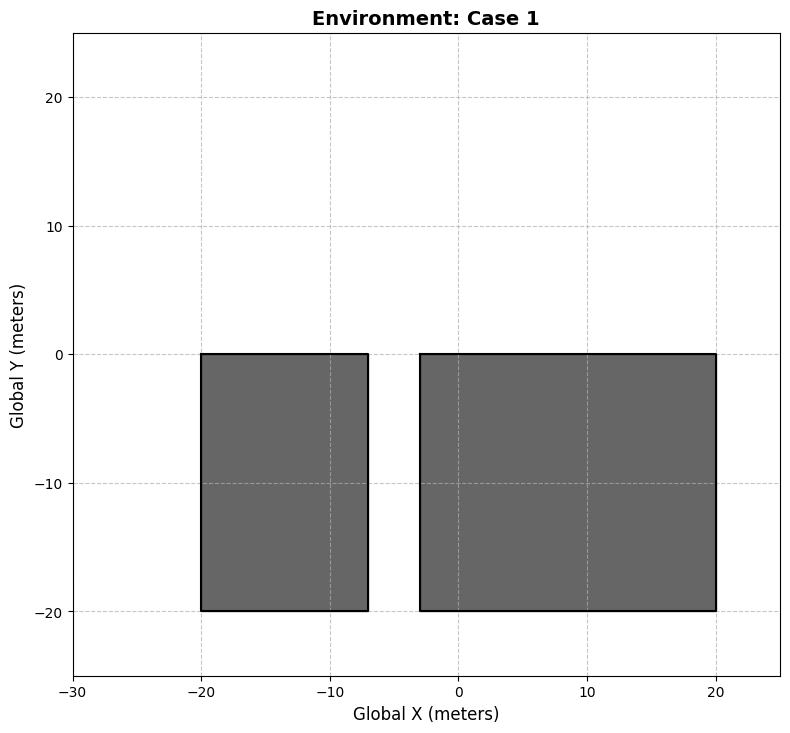

In [14]:
import matplotlib.pyplot as plt

def plot_obstacle_grid(base_obstacles, title="Obstacle Grid"):
    """
    Plots a given set of obstacle polygons on a 2D grid.
    
    Args:
        base_obstacles (list): A list of dictionaries, where each dict has 
                               'x' and 'y' lists representing polygon vertices.
    """
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Iterate through the obstacles and plot them
    for obs in base_obstacles:
        x = obs['x']
        y = obs['y']
        
        # Fill the inside of the obstacle
        ax.fill(x, y, color='black', alpha=0.6)
        
        # Draw the solid boundary line
        ax.plot(x, y, color='black', linewidth=1.5)
        
    # Standardize the plot aesthetics
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_aspect('equal') # CRITICAL: Ensures 1m in X looks identical to 1m in Y
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlabel('Global X (meters)', fontsize=12)
    ax.set_ylabel('Global Y (meters)', fontsize=12)
    
    # Set bounds based on the known planning scale of the warehouse
    ax.set_xlim(-30, 25)
    ax.set_ylim(-25, 25)
    
    # Render the plot
    plt.tight_layout()
    plt.show()


plot_obstacle_grid(BASE_OBSTACLES, title="Environment: Case 1")

In [15]:
import numpy as np
from matplotlib.path import Path

# Assumes Block 1 globals: SCALE, GEO, PHYS, ASTAR, BVC, BASE_OBSTACLES are already defined.

# ==============================================================================
# 3. DISCRETE GRID & COSTMAP GENERATION
# ==============================================================================

def create_costmap(planning_scale, hybrid_astar, obstacles):
    """
    Generates a binary 2D occupancy grid.
    1 = Obstacle cell, 0 = Free space.
    """
    num_x  = hybrid_astar['num_nodes_x']
    num_y  = hybrid_astar['num_nodes_y']
    res_x  = hybrid_astar['resolution_x']
    res_y  = hybrid_astar['resolution_y']
    xmin   = planning_scale['xmin']
    ymin   = planning_scale['ymin']

    # SANITY
    assert num_x > 0 and num_y > 0, "Grid dimensions must be positive."
    assert res_x > 0 and res_y > 0, "Grid resolutions must be positive."

    costmap = np.zeros((num_x, num_y), dtype=np.uint8)

    # Build grid of all cell centres
    x_coords  = xmin + np.arange(num_x) * res_x
    y_coords  = ymin + np.arange(num_y) * res_y
    xx, yy    = np.meshgrid(x_coords, y_coords, indexing='ij')
    grid_pts  = np.c_[xx.ravel(), yy.ravel()]   # (num_x*num_y, 2)

    total_obstacle_cells = 0
    for i, obs in enumerate(obstacles):
        vertices  = np.column_stack((obs['x'], obs['y']))
        poly_path = Path(vertices)
        inside    = poly_path.contains_points(grid_pts).reshape((num_x, num_y))
        costmap[inside] = 1
        n_cells = int(inside.sum())
        total_obstacle_cells += n_cells
        print(f"[COSTMAP] Obstacle {i}: {n_cells} cells marked occupied.")

    free_pct = 100.0 * (1 - costmap.sum() / costmap.size)
    print(f"[COSTMAP] Grid {num_x}×{num_y} = {costmap.size} cells. "
          f"Occupied: {total_obstacle_cells} ({100-free_pct:.1f}%). "
          f"Free: {free_pct:.1f}%.")

    # SANITY: At least some free space must exist
    assert costmap.sum() < costmap.size, \
        "Costmap is fully occupied — check obstacle definitions or grid bounds."

    return costmap


def convert_2d_config_to_index(x, y, planning_scale, hybrid_astar):
    """
    Converts continuous (x, y) to discrete costmap grid indices.
    Uses np.clip so indices are always valid (no out-of-bounds).
    """
    ind1 = int(np.ceil((x - planning_scale['xmin']) / hybrid_astar['resolution_x']))
    ind2 = int(np.ceil((y - planning_scale['ymin']) / hybrid_astar['resolution_y']))
    ind1 = int(np.clip(ind1, 0, hybrid_astar['num_nodes_x'] - 1))
    ind2 = int(np.clip(ind2, 0, hybrid_astar['num_nodes_y'] - 1))
    return ind1, ind2


def regulate_angle(angle):
    """Maps any angle to [0, 2π)."""
    return angle % (2.0 * np.pi)


def convert_6dim_config_to_index(node, planning_scale, hybrid_astar):
    """
    Converts the full 6-DOF state [x, y, θ1, θ2, θ3, θ4] into a
    discrete 6-tuple for use as a Hybrid A* closed-set key.
    """
    ind1, ind2 = convert_2d_config_to_index(node[0], node[1], planning_scale, hybrid_astar)
    max_th = hybrid_astar['num_nodes_theta'] - 1

    def angle_idx(theta):
        return int(np.clip(
            int(np.ceil(regulate_angle(theta) / hybrid_astar['resolution_theta'])),
            0, max_th
        ))

    return (ind1, ind2,
            angle_idx(node[2]), angle_idx(node[3]),
            angle_idx(node[4]), angle_idx(node[5]))


# ==============================================================================
# 4. KINEMATIC COLLISION CHECKERS
# ==============================================================================

def _get_rectangle_corners(cx, cy, theta, front_ext, rear_ext, half_width):
    """
    Returns the 4 corners (PX, PY) of a rectangle centred on (cx,cy),
    oriented at angle theta, extending front_ext forward and rear_ext backward.
    """
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    # Front-left, Front-right, Rear-right, Rear-left
    AX = cx + front_ext * cos_t - half_width * sin_t
    AY = cy + front_ext * sin_t + half_width * cos_t
    BX = cx + front_ext * cos_t + half_width * sin_t
    BY = cy + front_ext * sin_t - half_width * cos_t
    CX = cx - rear_ext  * cos_t + half_width * sin_t
    CY = cy - rear_ext  * sin_t - half_width * cos_t
    DX = cx - rear_ext  * cos_t - half_width * sin_t
    DY = cy - rear_ext  * sin_t + half_width * cos_t
    return np.array([AX, BX, CX, DX]), np.array([AY, BY, CY, DY])


def is_tractor_state_valid(x1, y1, theta1, vehicle_geometrics,
                            planning_scale, costmap, hybrid_astar):
    """
    Returns True if the tractor footprint is inside map bounds AND collision-free.

    The tractor's reference point (x1, y1) is the rear-axle centre.
    Front extension = L_tractor_wheelbase + L_tractor_front_hang
    Rear  extension = L_tractor_rear_hang
    """
    front_ext  = vehicle_geometrics['L_tractor_wheelbase'] + vehicle_geometrics['L_tractor_front_hang']
    rear_ext   = vehicle_geometrics['L_tractor_rear_hang']
    half_width = vehicle_geometrics['LHW']

    PX, PY = _get_rectangle_corners(x1, y1, theta1, front_ext, rear_ext, half_width)

    # 1. Boundary check
    if (np.any(PX > planning_scale['xmax']) or np.any(PX < planning_scale['xmin']) or
            np.any(PY > planning_scale['ymax']) or np.any(PY < planning_scale['ymin'])):
        return False

    # 2. Costmap check (each corner)
    for px, py in zip(PX, PY):
        ix, iy = convert_2d_config_to_index(px, py, planning_scale, hybrid_astar)
        if costmap[ix, iy] == 1:
            return False

    return True


def is_trailer_state_valid(x, y, theta, vehicle_geometrics,
                            planning_scale, costmap, hybrid_astar):
    """
    Returns True if a trailer footprint is inside map bounds AND collision-free.

    The trailer's reference point (x, y) is its rear-axle centre.
    Front extension = L_trailer_front_hang  (the part ahead of the axle, toward hitch)
    Rear  extension = L_trailer_rear_hang
    """
    front_ext  = vehicle_geometrics['L_trailer_front_hang']
    rear_ext   = vehicle_geometrics['L_trailer_rear_hang']
    half_width = vehicle_geometrics['LHW']

    PX, PY = _get_rectangle_corners(x, y, theta, front_ext, rear_ext, half_width)

    if (np.any(PX > planning_scale['xmax']) or np.any(PX < planning_scale['xmin']) or
            np.any(PY > planning_scale['ymax']) or np.any(PY < planning_scale['ymin'])):
        return False

    for px, py in zip(PX, PY):
        ix, iy = convert_2d_config_to_index(px, py, planning_scale, hybrid_astar)
        if costmap[ix, iy] == 1:
            return False

    return True


def is_6d_node_valid(x1, y1, theta1, theta2, theta3, theta4,
                     vehicle_geometrics, planning_scale, costmap, hybrid_astar):
    """
    Master validity check for a full 6-DOF tractor-trailer state.

    Steps:
      1. Jackknife check  — relative angle between consecutive units must be < 90 deg
      2. Tractor footprint check
      3. Compute trailer positions via kinematics
      4. Trailer footprint checks
    """
    # 1. Jackknife check
    #    The relevant angles are the RELATIVE articulation angles between consecutive units.
    angles = [theta1, theta2, theta3, theta4]
    for i in range(len(angles) - 1):
        diff = abs(angles[i] - angles[i + 1])
        # Wrap to [0, π]
        diff = min(diff, 2 * np.pi - diff)
        if diff > np.pi / 2:
            return False  # Jackknife detected

    # 2. Tractor collision
    if not is_tractor_state_valid(x1, y1, theta1,
                                   vehicle_geometrics, planning_scale, costmap, hybrid_astar):
        return False

    # 3. Compute trailer axle positions
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(
        x1, y1, theta1, theta2, theta3, theta4, vehicle_geometrics
    )

    # 4. Trailer collisions
    for (tx, ty, tth) in [(x2, y2, theta2), (x3, y3, theta3), (x4, y4, theta4)]:
        if not is_trailer_state_valid(float(tx), float(ty), float(tth),
                                       vehicle_geometrics, planning_scale, costmap, hybrid_astar):
            return False

    return True


# ==============================================================================
# --- RUN COLLISION MATH INITIALIZATION ---
# ==============================================================================
COSTMAP = create_costmap(SCALE, ASTAR, BASE_OBSTACLES)

# ---- SANITY: Verify start and goal are not inside obstacles ----
start_valid = is_6d_node_valid(
    BVC['x1_init'], BVC['y1_init'],
    BVC['theta1_init'], BVC['theta2_init'], BVC['theta3_init'], BVC['theta4_init'],
    GEO, SCALE, COSTMAP, ASTAR
)
goal_valid = is_tractor_state_valid(
    BVC['norminal_x1_end'], BVC['norminal_y1_end'],
    BVC['norminal_theta1_end'],
    GEO, SCALE, COSTMAP, ASTAR
)

print(f"\n[BLOCK 2 SANITY] Start state valid  : {'✓ YES' if start_valid else '✗ NO — START IS IN COLLISION!'}")
print(f"[BLOCK 2 SANITY] Goal  state valid  : {'✓ YES' if goal_valid  else '✗ NO — GOAL  IS IN COLLISION!'}")

if not start_valid:
    raise RuntimeError("Start configuration is in collision or out of bounds. "
                       "Check BVC start coordinates vs obstacle layout.")
if not goal_valid:
    raise RuntimeError("Goal configuration is in collision or out of bounds. "
                       "Check BVC goal coordinates vs obstacle layout.")

print("[BLOCK 2 COMPLETE] Costmap and collision checkers ready.\n")

[COSTMAP] Obstacle 0: 11571 cells marked occupied.
[COSTMAP] Obstacle 1: 20349 cells marked occupied.
[COSTMAP] Grid 335×268 = 89780 cells. Occupied: 31920 (35.6%). Free: 64.4%.

[BLOCK 2 SANITY] Start state valid  : ✓ YES
[BLOCK 2 SANITY] Goal  state valid  : ✓ YES
[BLOCK 2 COMPLETE] Costmap and collision checkers ready.



In [16]:
import numpy as np
import heapq
import time


_old = ASTAR['terminal_xy_neiborhood']
ASTAR['terminal_xy_neiborhood'] = 1.5
print(f"[BUG 1 FIX] terminal_xy_neiborhood: {_old} m  →  {ASTAR['terminal_xy_neiborhood']} m")


# ==============================================================================
# 5. HEURISTICS & 2D A*
# ==============================================================================

def calculate_h_2d(node_index, goal_idx):
    return abs(node_index[0] - goal_idx[0]) + abs(node_index[1] - goal_idx[1])


def generate_astar_path(begin_config, end_config, costmap, planning_scale, hybrid_astar):
    """Standard 2-D A*.  Returns approximate arc-length in metres, or 0 on failure."""
    goal_idx = convert_2d_config_to_index(end_config[0], end_config[1], planning_scale, hybrid_astar)
    init_idx  = convert_2d_config_to_index(begin_config[0], begin_config[1], planning_scale, hybrid_astar)
    if costmap[init_idx[0], init_idx[1]] == 1 or costmap[goal_idx[0], goal_idx[1]] == 1:
        return 0.0

    num_x, num_y = hybrid_astar['num_nodes_x'], hybrid_astar['num_nodes_y']
    closed_set   = set()
    open_heap    = []
    heapq.heappush(open_heap, (calculate_h_2d(init_idx, goal_idx), 0.0, init_idx))
    g_scores     = {init_idx: 0.0}
    neighbours   = [(-1,1,1.414),(-1,0,1.),(-1,-1,1.414),(0,1,1.),(0,-1,1.),(1,1,1.414),(1,0,1.),(1,-1,1.414)]

    for _ in range(500):
        if not open_heap:
            break
        _, cg, ci = heapq.heappop(open_heap)
        if ci == goal_idx:
            return cg * hybrid_astar['resolution_x']
        if ci in closed_set:
            continue
        closed_set.add(ci)
        for dx, dy, mc in neighbours:
            nb = (ci[0]+dx, ci[1]+dy)
            if not (0 <= nb[0] < num_x and 0 <= nb[1] < num_y):
                continue
            if costmap[nb[0], nb[1]] == 1:
                continue
            tg = cg + mc
            if nb not in g_scores or tg < g_scores[nb]:
                g_scores[nb] = tg
                heapq.heappush(open_heap, (tg + calculate_h_2d(nb, goal_idx), tg, nb))
    return 0.0


def calculate_h(node_6d, bvc, costmap, planning_scale, hybrid_astar):
    end_xy    = [bvc['norminal_x1_end'], bvc['norminal_y1_end']]
    h_holo    = generate_astar_path(node_6d[:2], end_xy, costmap, planning_scale, hybrid_astar)
    h_dist    = np.hypot(end_xy[0]-node_6d[0], end_xy[1]-node_6d[1])
    ang_err   = abs(node_6d[2]-bvc['norminal_theta1_end'])
    ang_err   = min(ang_err, 2*np.pi - ang_err)
    return hybrid_astar['multiplier_H'] * max(h_dist + ang_err*2.0, h_holo)


# ==============================================================================
# 6. KINEMATIC FORWARD SIMULATION  (Euler bug fixed — see Block 3 prev. version)
# ==============================================================================

def simulate_forward(node_6d, v, phy, vehicle_geometrics):
    """
    Euler integration: position updated with theta at the START of each sub-step,
    then heading is updated.  (Original code wrongly used theta_next for position.)
    """
    x0, y0, th1_0, th2_0, th3_0, th4_0 = node_6d
    L_wb = vehicle_geometrics['L_tractor_wheelbase']
    Nfe  = 20
    dt   = 1.0 / Nfe
    phy  = float(np.clip(phy, -np.pi/2+1e-6, np.pi/2-1e-6))

    xt  = np.empty(Nfe); xt[0]  = x0
    yt  = np.empty(Nfe); yt[0]  = y0
    th1 = np.empty(Nfe); th1[0] = th1_0

    for i in range(1, Nfe):
        tc     = th1[i-1]
        xt[i]  = xt[i-1]  + dt * np.cos(tc) * v   # ← use theta_current
        yt[i]  = yt[i-1]  + dt * np.sin(tc) * v
        th1[i] = tc        + dt * np.tan(phy) * v / L_wb

    M  = vehicle_geometrics['M']
    L  = vehicle_geometrics['L']
    th2 = np.empty(Nfe); th2[0] = th2_0
    th3 = np.empty(Nfe); th3[0] = th3_0
    th4 = np.empty(Nfe); th4[0] = th4_0

    for i in range(1, Nfe):
        dx   = xt[i]-xt[i-1]; dy = yt[i]-yt[i-1]
        tp   = th1[i-1]
        cp, sp = np.cos(tp), np.sin(tp)
        ds1  = dx/(cp+1e-9) if abs(cp)>=abs(sp) else dy/(sp+1e-9)
        dth1 = th1[i]-th1[i-1]

        a1      = tp - th2[i-1]
        dth2    = (ds1*np.sin(a1) - M[0]*np.cos(a1)*dth1) / L[1]
        th2[i]  = th2[i-1] + dth2
        ds2     = ds1*np.cos(a1) + M[0]*np.sin(a1)*dth1

        a2      = th2[i-1]-th3[i-1]
        dth3    = (ds2*np.sin(a2) - M[1]*np.cos(a2)*dth2) / L[2]
        th3[i]  = th3[i-1] + dth3
        ds3     = ds2*np.cos(a2) + M[1]*np.sin(a2)*dth2

        a3      = th3[i-1]-th4[i-1]
        dth4    = (ds3*np.sin(a3) - M[2]*np.cos(a3)*dth3) / L[3]
        th4[i]  = th4[i-1] + dth4

    return xt, yt, th1, th2, th3, th4


# ==============================================================================
# 7. HYBRID A* MAIN LOOP
# ==============================================================================

def plan_hybrid_astar_path(bvc, hybrid_astar, vehicle_physics, vehicle_geometrics,
                            planning_scale, costmap):
    print("[HYBRID A*] Starting …")
    t0 = time.time()

    init_6d   = (bvc['x1_init'], bvc['y1_init'],
                 bvc['theta1_init'], bvc['theta2_init'],
                 bvc['theta3_init'], bvc['theta4_init'])
    init_h    = calculate_h(init_6d, bvc, costmap, planning_scale, hybrid_astar)
    init_hist = ([init_6d[0]], [init_6d[1]], [init_6d[2]],
                 [init_6d[3]], [init_6d[4]], [init_6d[5]])

    # Tie-breaker (int) stops Python comparing list-containing path history tuples
    ctr = 0
    heap = []
    heapq.heappush(heap, (init_h, ctr, 0.0, init_6d, init_hist))
    closed  = set()
    best_h, best_hist = init_h, init_hist   # always-defined fallback

    expns = [
        ( 1., -vehicle_physics['phy_max']), ( 1., 0.), ( 1., vehicle_physics['phy_max']),
        (-1., -vehicle_physics['phy_max']), (-1., 0.), (-1., vehicle_physics['phy_max']),
    ]

    for it in range(1, hybrid_astar['max_iter'] + 1):
        if not heap:
            print(f"[HYBRID A*] Heap empty at iter {it-1}.")
            break

        f, _tb, g, cur6d, hist = heapq.heappop(heap)

        h_now = f - g
        if h_now < best_h:
            best_h, best_hist = h_now, hist

        gidx = convert_6dim_config_to_index(cur6d, planning_scale, hybrid_astar)
        if gidx in closed:
            continue
        closed.add(gidx)

        dist_goal = np.hypot(cur6d[0]-bvc['norminal_x1_end'],
                             cur6d[1]-bvc['norminal_y1_end'])
        if dist_goal < hybrid_astar['terminal_xy_neiborhood']:
            ae = min(abs(cur6d[2]-bvc['norminal_theta1_end']),
                     2*np.pi - abs(cur6d[2]-bvc['norminal_theta1_end']))
            print(f"[HYBRID A*] ✓  iter={it}  dist={dist_goal:.3f} m  "
                  f"angle_err={np.degrees(ae):.1f}°  |closed|={len(closed)}  "
                  f"time={time.time()-t0:.2f} s")
            return hist

        for v, phy in expns:
            xt,yt,t1,t2,t3,t4 = simulate_forward(cur6d, v, phy, vehicle_geometrics)
            ch = (float(xt[-1]),float(yt[-1]),float(t1[-1]),
                  float(t2[-1]),float(t3[-1]),float(t4[-1]))
            if not is_6d_node_valid(ch[0],ch[1],ch[2],ch[3],ch[4],ch[5],
                                    vehicle_geometrics,planning_scale,costmap,hybrid_astar):
                continue
            mc = 1.0
            if v < 0: mc *= hybrid_astar['penalty_multiplier_for_reversing']
            if abs(phy) > 1e-6: mc *= 1.2
            cg = g + mc
            ch_h = calculate_h(ch, bvc, costmap, planning_scale, hybrid_astar)
            new_hist = (hist[0]+xt.tolist(), hist[1]+yt.tolist(),
                        hist[2]+t1.tolist(), hist[3]+t2.tolist(),
                        hist[4]+t3.tolist(), hist[5]+t4.tolist())
            ctr += 1
            heapq.heappush(heap, (cg+ch_h, ctr, cg, ch, new_hist))

        if it % 50 == 0:
            print(f"[HYBRID A*]  iter {it:4d}/{hybrid_astar['max_iter']} | "
                  f"|closed|={len(closed):5d} | |open|={len(heap):6d} | "
                  f"best_h={best_h:.2f}")

    print(f"[HYBRID A*] ✗ Max iterations. Returning best node (h={best_h:.3f}). "
          f"time={time.time()-t0:.1f} s")
    return best_hist


# ==============================================================================
# SANITY — quick self-test of simulate_forward
# ==============================================================================
def _sanity_simulate():
    print("[SANITY simulate_forward] …")
    z = (0.,0.,0.,0.,0.,0.)
    x,y,th1,*_ = simulate_forward(z, 0., 0., GEO)
    assert np.allclose(x,0,atol=1e-10) and np.allclose(y,0,atol=1e-10), "zero-v: must stay put"
    print("  [1/3] zero velocity → stationary ✓")
    x,y,th1,*_ = simulate_forward(z, 1., 0., GEO)
    assert np.all(np.abs(y)<1e-10) and np.all(np.diff(x)>0), "straight: must go along +X"
    print("  [2/3] straight → +X motion ✓")
    x,y,th1,*_ = simulate_forward(z, 1., PHYS['phy_max'], GEO)
    assert th1[-1]>0 and y[-1]>0, "left turn: heading and y must be positive"
    print(f"  [3/3] left turn → heading={np.degrees(th1[-1]):.2f}°, y={y[-1]:.4f} ✓")
    print("[SANITY simulate_forward] all passed.\n")

_sanity_simulate()

# ==============================================================================
# RUN
# ==============================================================================
PATH_HISTORY = plan_hybrid_astar_path(BVC, ASTAR, PHYS, GEO, SCALE, COSTMAP)

print("\n[BLOCK 3 SANITY]")
px, py = PATH_HISTORY[0], PATH_HISTORY[1]
assert len(px) > 1
arc_len  = float(np.sum(np.hypot(np.diff(px), np.diff(py))))
end_dist = np.hypot(px[-1]-BVC['norminal_x1_end'], py[-1]-BVC['norminal_y1_end'])
print(f"  Points     : {len(px)}")
print(f"  Arc length : {arc_len:.2f} m")
print(f"  Start      : ({px[0]:.2f}, {py[0]:.2f})")
print(f"  End        : ({px[-1]:.2f}, {py[-1]:.2f})")
print(f"  Goal       : ({BVC['norminal_x1_end']:.2f}, {BVC['norminal_y1_end']:.2f})")
print(f"  End→goal   : {end_dist:.2f} m  "
      f"({'✓' if end_dist<=1.5 else '⚠ A* hit max_iter before goal'})")
print("[BLOCK 3 COMPLETE]\n")

[BUG 1 FIX] terminal_xy_neiborhood: 5.0 m  →  1.5 m
[SANITY simulate_forward] …
  [1/3] zero velocity → stationary ✓
  [2/3] straight → +X motion ✓
  [3/3] left turn → heading=30.56°, y=0.2347 ✓
[SANITY simulate_forward] all passed.

[HYBRID A*] Starting …
[HYBRID A*]  iter   50/30000 | |closed|=   48 | |open|=   157 | best_h=63.13
[HYBRID A*]  iter  150/30000 | |closed|=  121 | |open|=   357 | best_h=49.41
[HYBRID A*]  iter  200/30000 | |closed|=  153 | |open|=   444 | best_h=46.70
[HYBRID A*]  iter  250/30000 | |closed|=  187 | |open|=   543 | best_h=44.02
[HYBRID A*]  iter  300/30000 | |closed|=  214 | |open|=   609 | best_h=41.36
[HYBRID A*]  iter  350/30000 | |closed|=  247 | |open|=   701 | best_h=38.73
[HYBRID A*]  iter  400/30000 | |closed|=  279 | |open|=   787 | best_h=38.73
[HYBRID A*]  iter  500/30000 | |closed|=  342 | |open|=   967 | best_h=36.14
[HYBRID A*]  iter  700/30000 | |closed|=  470 | |open|=  1329 | best_h=36.14
[HYBRID A*]  iter  800/30000 | |closed|=  530 | |o

Generating Hybrid A* visualization...


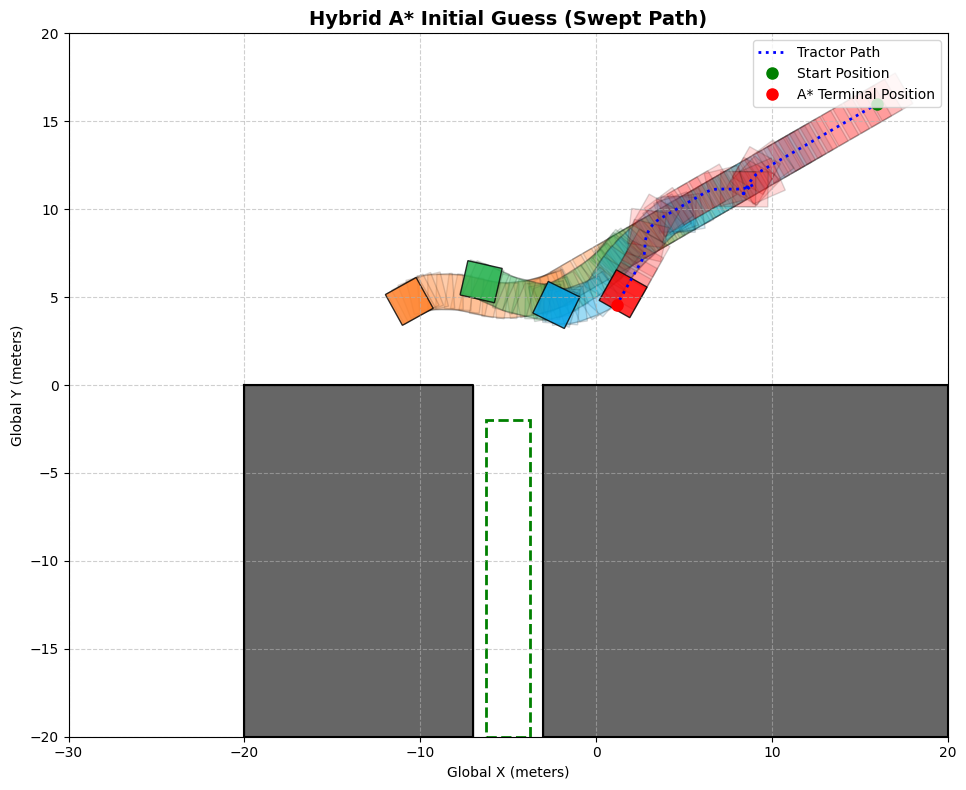

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==============================================================================
# DRAWING HELPER FOR STATIC PLOTS
# ==============================================================================
def draw_vehicle_state(ax, x1, y1, th1, th2, th3, th4, geo, color_alpha=0.3):
    """Draws the tractor and 3 trailers at a specific state on the given axes."""
    LHW = geo['LHW']
    
    # 1. Tractor Footprint
    L_front = geo['L_tractor_front_hang']
    L_wb = geo['L_tractor_wheelbase']
    L_rear = geo['L_tractor_rear_hang']
    front_ext = L_front + L_wb
    
    tractor_poly = np.array([
        [x1 + front_ext*np.cos(th1) - LHW*np.sin(th1), y1 + front_ext*np.sin(th1) + LHW*np.cos(th1)],
        [x1 + front_ext*np.cos(th1) + LHW*np.sin(th1), y1 + front_ext*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) + LHW*np.sin(th1), y1 - L_rear*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) - LHW*np.sin(th1), y1 - L_rear*np.sin(th1) + LHW*np.cos(th1)]
    ])
    ax.add_patch(patches.Polygon(tractor_poly, closed=True, facecolor='red', edgecolor='black', alpha=color_alpha))

    # 2. Trailer Footprints
    # Expand coordinates using the kinematics
    M, L = geo['M'], geo['L']
    x2 = x1 - M[0]*np.cos(th1) - L[1]*np.cos(th2)
    y2 = y1 - M[0]*np.sin(th1) - L[1]*np.sin(th2)
    x3 = x2 - M[1]*np.cos(th2) - L[2]*np.cos(th3)
    y3 = y2 - M[1]*np.sin(th2) - L[2]*np.sin(th3)
    x4 = x3 - M[2]*np.cos(th3) - L[3]*np.cos(th4)
    y4 = y3 - M[2]*np.sin(th3) - L[3]*np.sin(th4)
    
    trailer_states = [(x2, y2, th2), (x3, y3, th3), (x4, y4, th4)]
    t_front, t_rear = geo['L_trailer_front_hang'], geo['L_trailer_rear_hang']
    colors = ['#00A2E8', '#22B14C', '#FF7F27'] # Cyan, Green, Orange
    
    for i, (tx, ty, t_th) in enumerate(trailer_states):
        trailer_poly = np.array([
            [tx + t_front*np.cos(t_th) - LHW*np.sin(t_th), ty + t_front*np.sin(t_th) + LHW*np.cos(t_th)],
            [tx + t_front*np.cos(t_th) + LHW*np.sin(t_th), ty + t_front*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) + LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) - LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) + LHW*np.cos(t_th)]
        ])
        ax.add_patch(patches.Polygon(trailer_poly, closed=True, facecolor=colors[i], edgecolor='black', alpha=color_alpha))

# ==============================================================================
# MAIN PLOTTING FUNCTION
# ==============================================================================
def plot_hybrid_astar_trajectory(path_history, obstacles, bvc, scale, geo, sample_step=15):
    """
    Visualizes the Hybrid A* path history on the warehouse grid.
    
    Args:
        path_history (tuple): The 6-element tuple of lists (x, y, th1, th2, th3, th4) returned by A*.
        sample_step (int): Draws the vehicle footprints every Nth point to avoid clutter.
    """
    print("Generating Hybrid A* visualization...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Setup Canvas
    ax.set_xlim(scale['xmin'], scale['xmax'])
    ax.set_ylim(scale['ymin'], scale['ymax'])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title("Hybrid A* Initial Guess (Swept Path)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Global X (meters)")
    ax.set_ylabel("Global Y (meters)")

    # 2. Draw Obstacles
    for obs in obstacles:
        ax.fill(obs['x'], obs['y'], color='black', alpha=0.6)
        ax.plot(obs['x'], obs['y'], color='black', linewidth=1.5)

    # 3. Draw Goal Region (Green Dashed Box)
    goal_box = patches.Rectangle(
        (bvc['xc_end'] - bvc['x_end_half_width'], bvc['yc_end'] - bvc['y_end_half_width']),
        bvc['x_end_half_width'] * 2, bvc['y_end_half_width'] * 2,
        linewidth=2, edgecolor='green', facecolor='none', linestyle='--'
    )
    ax.add_patch(goal_box)

    # Extract arrays
    x_traj, y_traj = path_history[0], path_history[1]
    th1, th2 = path_history[2], path_history[3]
    th3, th4 = path_history[4], path_history[5]
    
    total_points = len(x_traj)
    
    # 4. Draw the Tractor's Centerline Path
    ax.plot(x_traj, y_traj, color='blue', linewidth=2, linestyle=':', label="Tractor Path")
    
    # 5. Draw Vehicle Footprints at sampled intervals
    # We sample the array to keep the plot readable (e.g., every 15th simulation step)
    for i in range(0, total_points, sample_step):
        draw_vehicle_state(ax, x_traj[i], y_traj[i], th1[i], th2[i], th3[i], th4[i], geo, color_alpha=0.15)
        
    # Ensure the very last point is drawn at full opacity to see where A* stopped
    draw_vehicle_state(ax, x_traj[-1], y_traj[-1], th1[-1], th2[-1], th3[-1], th4[-1], geo, color_alpha=0.8)

    # 6. Add start and end markers for clarity
    ax.plot(x_traj[0], y_traj[0], 'go', markersize=8, label='Start Position')
    ax.plot(x_traj[-1], y_traj[-1], 'ro', markersize=8, label='A* Terminal Position')

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_hybrid_astar_trajectory(PATH_HISTORY, BASE_OBSTACLES, BVC, SCALE, GEO, sample_step=15)


In [18]:
import casadi as ca
import numpy as np
from scipy.interpolate import interp1d
import time

# Assumes Block 1-3 globals in scope:
#   SCALE, GEO, PHYS, ASTAR, BVC, BASE_OBSTACLES, PATH_HISTORY

# ==============================================================================
# 8. TRAJECTORY RESAMPLING  (duplicate-point fix retained from previous version)
# ==============================================================================

def resample_config(path_hist, num_points=101):
    """
    Resamples the Hybrid A* waypoints to exactly num_points arc-length-uniform points.
    Deduplicates coincident points before computing arc lengths to prevent interp1d crash.
    """
    arrays = [np.array(a, dtype=float) for a in path_hist]
    x, y, th1, th2, th3, th4 = arrays
    n_raw = len(x)
    assert n_raw >= 2

    # Deduplicate consecutive identical (x,y) pairs
    dists = np.hypot(np.diff(x), np.diff(y))
    keep  = np.concatenate(([True], dists > 1e-9))
    x, y, th1, th2, th3, th4 = (a[keep] for a in [x, y, th1, th2, th3, th4])
    n_dd = int(keep.sum())
    if n_dd < n_raw:
        print(f"[RESAMPLE] Removed {n_raw-n_dd} duplicate points ({n_raw}→{n_dd}).")
    assert n_dd >= 2, "Fewer than 2 unique points after dedup — degenerate A* trajectory."

    s      = np.concatenate(([0.], np.cumsum(np.hypot(np.diff(x), np.diff(y)))))
    assert np.all(np.diff(s) > 0), "Arc lengths not strictly increasing after dedup."
    s_n    = s / s[-1]
    s_tgt  = np.linspace(0., 1., num_points)

    result = {
        'x':   interp1d(s_n, x,             kind='linear')(s_tgt),
        'y':   interp1d(s_n, y,             kind='linear')(s_tgt),
        'th1': interp1d(s_n, np.unwrap(th1), kind='linear')(s_tgt),
        'th2': interp1d(s_n, np.unwrap(th2), kind='linear')(s_tgt),
        'th3': interp1d(s_n, np.unwrap(th3), kind='linear')(s_tgt),
        'th4': interp1d(s_n, np.unwrap(th4), kind='linear')(s_tgt),
    }
    print(f"[RESAMPLE] {n_dd} pts → {num_points} pts. Arc length: {s[-1]:.2f} m.")
    return result, float(s[-1])    # return arc length too — needed for dt estimate


# ==============================================================================
# 9. HOMOTOPY OBSTACLE SCALING  (unchanged logic, added sanity)
# ==============================================================================

def scale_obstacles(base_obstacles, gamma):
    """Scales each obstacle about its centroid. gamma=0→point, gamma=1→full size."""
    gamma = float(np.clip(gamma, 0., 1.))
    scaled = []
    for obs in base_obstacles:
        xa, ya = np.array(obs['x'], dtype=float), np.array(obs['y'], dtype=float)
        assert np.isclose(xa[0], xa[-1]) and np.isclose(ya[0], ya[-1]), \
            "Obstacle polygon must be closed."
        cx, cy = float(np.mean(xa[:-1])), float(np.mean(ya[:-1]))
        scaled.append({'x': (cx + (xa-cx)*gamma).tolist(),
                       'y': (cy + (ya-cy)*gamma).tolist()})
    return scaled


def compute_halfplanes(obs_x, obs_y):
    """
    Given a closed convex polygon (last point == first point), return a list of
    (nx, ny, offset) tuples where:
        nx*px + ny*py  >=  offset   means the point is OUTSIDE this edge.

    The outward normal is computed from the CCW-oriented vertex list.
    If the input is CW, we reverse it to CW → CCW first.
    """
    vx = list(obs_x[:-1])
    vy = list(obs_y[:-1])
    n  = len(vx)
    assert n >= 3, "Need at least 3 vertices."

    # Signed area: positive → CCW, negative → CW
    area2 = sum(vx[i]*vy[(i+1)%n] - vx[(i+1)%n]*vy[i] for i in range(n))
    if area2 < 0:          # CW → reverse to CCW
        vx, vy = vx[::-1], vy[::-1]

    planes = []
    for i in range(n):
        j  = (i+1) % n
        dx, dy = vx[j]-vx[i], vy[j]-vy[i]
        L  = np.hypot(dx, dy)
        if L < 1e-9:
            continue
        # For CCW polygon: outward normal = 90° CW rotation of edge direction
        nx, ny = dy/L, -dx/L
        offset = nx*vx[i] + ny*vy[i]
        planes.append((float(nx), float(ny), float(offset)))
    return planes


def _sanity_halfplanes():
    """
    Verify halfplane logic on Case 3's left obstacle (a known rectangle).
    Left obstacle: x ∈ [-20,-7], y ∈ [-20,0]
    """
    obs_x = [-20, -7, -7, -20, -20]
    obs_y = [  0,  0,-20, -20,   0]
    planes = compute_halfplanes(obs_x, obs_y)
    assert len(planes) == 4, f"Expected 4 edges, got {len(planes)}"

    def signed_max(px, py):
        return max(nx*px + ny*py - offset for nx, ny, offset in planes)

    # Point clearly outside (to the right of the obstacle)
    sm_out = signed_max(-5., -10.)
    assert sm_out > 0., f"Point at (-5,-10) should be outside. signed_max={sm_out:.4f}"

    # Point clearly inside the obstacle
    sm_in = signed_max(-14., -10.)
    assert sm_in < 0., f"Point at (-14,-10) should be inside. signed_max={sm_in:.4f}"

    # Point exactly on the right boundary (x = -7) — should be ~0
    sm_edge = signed_max(-7., -10.)
    assert abs(sm_edge) < 1e-6, f"Point at (-7,-10) should be on boundary. signed_max={sm_edge:.4f}"

    print("[SANITY halfplanes] Left obstacle geometry verified ✓")
    print(f"  outside(-5,-10)  → signed_max = {sm_out:.4f}  (> 0 ✓)")
    print(f"  inside (-14,-10) → signed_max = {sm_in:.4f} (< 0 ✓)")
    print(f"  edge   (-7,-10)  → signed_max = {sm_edge:.6f} (≈ 0 ✓)\n")

_sanity_halfplanes()


def _smooth_outside(px, py, halfplanes, margin, scale=8.0):
    """
    Returns a CasADi scalar expression that is >= 0 when the point (px, py)
    is at least `margin` metres outside the polygon.

    Implementation: log-sum-exp approximation of max signed distance.
        smooth_max ≈ (1/scale) * log( Σ exp(scale * d_i) )
    where d_i = nx_i*px + ny_i*py - offset_i  (signed dist to edge i, + = outside).

    Accuracy: the smooth max overestimates the true max by at most log(n)/scale.
    With scale=8 and n=4 edges: error ≤ log(4)/8 ≈ 0.17 m, absorbed into margin.
    We clamp exp arguments at 50 to prevent float overflow in edge cases.
    """
    terms = [ca.exp(ca.fmin(scale*(nx*px + ny*py - off), 50.))
             for nx, ny, off in halfplanes]
    return ca.log(sum(terms)) / scale - margin



def solve_pcoc_nlp(initial_guess, halfplanes_per_obstacle,
                   bvc, vehicle_physics, vehicle_geometrics, dt_fixed):
    """
    Solves one NLP in the homotopy chain.

    Parameters
    ----------
    initial_guess          : dict with keys x,y,th1,th2,th3,th4 (each length N+1)
    halfplanes_per_obstacle: list of halfplane lists (one list per obstacle)
    dt_fixed               : fixed time-step scalar (NOT a decision variable)

    Returns (success: bool, result_dict)
    """
    N   = len(initial_guess['x']) - 1
    assert N >= 2, f"Need at least 3 waypoints. Got {N+1}."

    M   = vehicle_geometrics['M']
    L   = vehicle_geometrics['L']
    LHW = vehicle_geometrics['LHW']
    L_wb = vehicle_geometrics['L_tractor_wheelbase']

    # Obstacle avoidance margin = vehicle half-width + small safety buffer.
    # The smooth-max approximation error (≤ 0.17 m) is already inside this margin.
    OBS_MARGIN = LHW + 0.35    # metres

    opti = ca.Opti()

    # ── Decision variables ─────────────────────────────────────────────────
    X = opti.variable(6, N+1)   # [x, y, th1, th2, th3, th4]
    U = opti.variable(2, N)     # [v, phi]
    # dt is a FIXED CONSTANT — no longer a decision variable (Bug 3 fix)

    # ── Cost function ──────────────────────────────────────────────────────
    # Minimise control effort + smoothness (time is fixed, so we skip the
    # time-minimisation term that required variable dt).
    cost = 0
    for k in range(N):
        cost += ca.sumsqr(U[0, k]) * 1.0      # velocity magnitude
        cost += ca.sumsqr(U[1, k]) * 5.0      # steering magnitude
        if k < N-1:
            cost += ca.sumsqr(U[0, k+1] - U[0, k]) * 3.0   # acceleration
            cost += ca.sumsqr(U[1, k+1] - U[1, k]) * 3.0   # steering rate
    opti.minimize(cost)

    # ── Kinematic constraints (multiple shooting) ──────────────────────────
    for k in range(N):
        v   = U[0, k]
        phi = U[1, k]

        # ── Tractor ──────────────────────────────────────────────────────
        th1_k   = X[2, k]
        x_kp1   = X[0, k] + v * ca.cos(th1_k) * dt_fixed   # linear in v (Bug 3 fixed)
        y_kp1   = X[1, k] + v * ca.sin(th1_k) * dt_fixed   # linear in v
        th1_kp1 = th1_k   + (v * ca.tan(phi) / L_wb) * dt_fixed

        opti.subject_to(X[0, k+1] == x_kp1)
        opti.subject_to(X[1, k+1] == y_kp1)
        opti.subject_to(X[2, k+1] == th1_kp1)

        # ── Trailer 1 (θ2) — off-axle kinematic model ────────────────────
        # Arc-length step of tractor: ds1 = v * dt  (linear in v)
        ds1     = v * dt_fixed
        th2_k   = X[3, k]
        a1      = th1_k - th2_k
        dth1    = th1_kp1 - th1_k            # = (v*tan(phi)/L_wb)*dt_fixed
        dth2    = (ds1 * ca.sin(a1) - M[0] * ca.cos(a1) * dth1) / L[1]
        th2_kp1 = th2_k + dth2
        opti.subject_to(X[3, k+1] == th2_kp1)
        ds2     = ds1 * ca.cos(a1) + M[0] * ca.sin(a1) * dth1

        # ── Trailer 2 (θ3) ────────────────────────────────────────────────
        th3_k   = X[4, k]
        a2      = th2_k - th3_k
        dth3    = (ds2 * ca.sin(a2) - M[1] * ca.cos(a2) * dth2) / L[2]
        th3_kp1 = th3_k + dth3
        opti.subject_to(X[4, k+1] == th3_kp1)
        ds3     = ds2 * ca.cos(a2) + M[1] * ca.sin(a2) * dth2

        # ── Trailer 3 (θ4) ────────────────────────────────────────────────
        th4_k   = X[5, k]
        a3      = th3_k - th4_k
        dth4    = (ds3 * ca.sin(a3) - M[2] * ca.cos(a3) * dth3) / L[3]
        th4_kp1 = th4_k + dth4
        opti.subject_to(X[5, k+1] == th4_kp1)

    # ── Boundary conditions (start) ────────────────────────────────────────
    opti.subject_to(X[0, 0] == bvc['x1_init'])
    opti.subject_to(X[1, 0] == bvc['y1_init'])
    opti.subject_to(X[2, 0] == bvc['theta1_init'])
    opti.subject_to(X[3, 0] == bvc['theta2_init'])
    opti.subject_to(X[4, 0] == bvc['theta3_init'])
    opti.subject_to(X[5, 0] == bvc['theta4_init'])

    # ── Boundary conditions (goal — relaxed position box + heading band) ───
    half = 0.5
    opti.subject_to(opti.bounded(bvc['xc_end'] - half, X[0, N], bvc['xc_end'] + half))
    opti.subject_to(opti.bounded(bvc['yc_end'] - half, X[1, N], bvc['yc_end'] + half))
    # Heading at goal: allow ±0.3 rad (~17°) around nominal
    ang_tol = 0.3
    opti.subject_to(opti.bounded(bvc['norminal_theta1_end'] - ang_tol,
                                  X[2, N],
                                  bvc['norminal_theta1_end'] + ang_tol))

    # ── Control limits ─────────────────────────────────────────────────────
    opti.subject_to(opti.bounded(-vehicle_physics['v_max'],   U[0, :], vehicle_physics['v_max']))
    opti.subject_to(opti.bounded(-vehicle_physics['phy_max'], U[1, :], vehicle_physics['phy_max']))

    for halfplanes in halfplanes_per_obstacle:
        if not halfplanes:
            continue
        for k in range(N + 1):
            # -- Tractor --
            px_tr = X[0, k]
            py_tr = X[1, k]
            opti.subject_to(_smooth_outside(px_tr, py_tr, halfplanes, OBS_MARGIN) >= 0)

            # -- Trailer axle positions (symbolic, using state variables) --
            th1_k = X[2, k]; th2_k = X[3, k]
            th3_k = X[4, k]; th4_k = X[5, k]

            # Trailer 1 axle
            px_t1 = X[0, k] - M[0]*ca.cos(th1_k) - L[1]*ca.cos(th2_k)
            py_t1 = X[1, k] - M[0]*ca.sin(th1_k) - L[1]*ca.sin(th2_k)
            opti.subject_to(_smooth_outside(px_t1, py_t1, halfplanes, OBS_MARGIN) >= 0)

            # Trailer 2 axle
            px_t2 = px_t1 - M[1]*ca.cos(th2_k) - L[2]*ca.cos(th3_k)
            py_t2 = py_t1 - M[1]*ca.sin(th2_k) - L[2]*ca.sin(th3_k)
            opti.subject_to(_smooth_outside(px_t2, py_t2, halfplanes, OBS_MARGIN) >= 0)

            # Trailer 3 axle
            px_t3 = px_t2 - M[2]*ca.cos(th3_k) - L[3]*ca.cos(th4_k)
            py_t3 = py_t2 - M[2]*ca.sin(th3_k) - L[3]*ca.sin(th4_k)
            opti.subject_to(_smooth_outside(px_t3, py_t3, halfplanes, OBS_MARGIN) >= 0)

    # ── Warm start ─────────────────────────────────────────────────────────
    opti.set_initial(X[0, :], initial_guess['x'])
    opti.set_initial(X[1, :], initial_guess['y'])
    opti.set_initial(X[2, :], initial_guess['th1'])
    opti.set_initial(X[3, :], initial_guess['th2'])
    opti.set_initial(X[4, :], initial_guess['th3'])
    opti.set_initial(X[5, :], initial_guess['th4'])

    # Initial velocity estimate from arc length
    arc  = float(np.sum(np.hypot(np.diff(initial_guess['x']),
                                  np.diff(initial_guess['y']))))
    v0   = float(np.clip(arc / (N * dt_fixed), 0.05, vehicle_physics['v_max']))
    opti.set_initial(U[0, :], v0)
    opti.set_initial(U[1, :], 0.0)

    # ── Solver settings ────────────────────────────────────────────────────
    p_opts = {"expand": True}
    s_opts = {
        "max_iter": 1000,
        "print_level": 0,
        "acceptable_tol": 1e-3,
        "acceptable_iter": 5,
        "warm_start_init_point": "yes",
        "nlp_scaling_method": "gradient-based",
    }
    opti.solver("ipopt", p_opts, s_opts)

    # ── Solve ──────────────────────────────────────────────────────────────
    try:
        sol = opti.solve()
        res = {
            'x':   sol.value(X[0, :]),
            'y':   sol.value(X[1, :]),
            'th1': sol.value(X[2, :]),
            'th2': sol.value(X[3, :]),
            'th3': sol.value(X[4, :]),
            'th4': sol.value(X[5, :]),
        }
        return True, res
    except Exception as e:
        print(f"    [NLP FAIL] {type(e).__name__}: {str(e)[:120]}")
        try:
            return False, {k: opti.debug.value(X[i, :])
                           for i, k in enumerate(['x','y','th1','th2','th3','th4'])}
        except Exception:
            return False, initial_guess


# ==============================================================================
# SANITY — verify _smooth_outside on concrete numbers
# ==============================================================================
def _sanity_smooth_outside():
    """
    Test _smooth_outside on Case 3's left obstacle using plain numpy
    (not CasADi, to make the check fast and standalone).
    Left obstacle: x ∈ [-20,-7], y ∈ [-20,0]
    """
    obs_x = [-20, -7, -7, -20, -20]
    obs_y = [  0,  0,-20, -20,   0]
    planes = compute_halfplanes(obs_x, obs_y)
    scale  = 8.0

    def np_smooth_outside(px, py, margin):
        terms = [np.exp(min(scale*(nx*px+ny*py-off), 50.)) for nx,ny,off in planes]
        return np.log(sum(terms))/scale - margin

    margin = GEO['LHW'] + 0.35

    # Point safely outside (tractor in corridor at x=-5)
    val_out = np_smooth_outside(-5., -10., margin)
    assert val_out > 0., f"(-5,-10) outside corridor wall — smooth val should be > 0, got {val_out:.4f}"

    # Point inside the obstacle
    val_in = np_smooth_outside(-14., -10., margin)
    assert val_in < -margin + 0.5, f"(-14,-10) inside obstacle — smooth val should be < 0, got {val_in:.4f}"

    print(f"[SANITY smooth_outside] outside(-5,-10)={val_out:.4f} (>0 ✓)  "
          f"inside(-14,-10)={val_in:.4f} (<0 ✓)\n")

_sanity_smooth_outside()


# ==============================================================================
# 12. MASTER PCOC PIPELINE — all bugs fixed
# ==============================================================================

def run_full_pcoc_pipeline(path_history, base_obstacles, bvc, phys, geo, num_points=101):

    print("=" * 65)
    print("  PCOC PIPELINE — ALL BUGS FIXED")
    print("=" * 65)
    t0 = time.time()

    # ── Step 1: Resample ──────────────────────────────────────────────────
    print("\n[STEP 1] Resampling …")
    initial_guess, arc_len = resample_config(path_history, num_points=num_points)

    # ── Step 2: Compute fixed dt  (Bug 3) ─────────────────────────────────
    N         = num_points - 1
    v_target  = phys['v_max'] * 0.6          # assume 60% of max speed
    T_est     = arc_len / max(v_target, 0.1)
    dt_fixed  = float(np.clip(T_est / N, 0.05, 0.35))
    print(f"\n[BUG 3 FIX] dt_fixed = {dt_fixed:.4f} s  "
          f"(arc={arc_len:.2f} m, T_est={T_est:.1f} s, N={N})")
    print(f"            This eliminates the bilinear v×dt product in all "
          f"kinematic constraints.")

    # ── Step 3: Precompute full-size half-planes  (Bug 5) ─────────────────
    full_halfplanes = [compute_halfplanes(obs['x'], obs['y'])
                       for obs in base_obstacles]
    print(f"\n[BUG 5 FIX] Half-planes computed for {len(base_obstacles)} obstacles:")
    for i, hp in enumerate(full_halfplanes):
        print(f"            Obstacle {i}: {len(hp)} edges")

    # ── Step 4: Homotopy loop  (Bug 2: starts at gamma=0) ─────────────────
    print("\n[BUG 2 FIX] Starting homotopy at γ=0 (obstacle-free seed solve).")

    gamma_done  = 0.0
    step        = 0.1
    alpha_bt    = 0.8
    best_traj   = initial_guess
    n_success   = 0

    # ── γ = 0 seed solve (no obstacles → trivially feasible) ──────────────
    print(f"\n  γ = 0.000 (no obstacles — trivial seed) …", end="  ")
    ok, res = solve_pcoc_nlp(initial_guess, [],
                              bvc, phys, geo, dt_fixed)
    if ok:
        best_traj = res
        print("✓  Seed solution found.")
    else:
        print("✗  Seed failed — proceeding with A* guess (NLP may struggle).")

    # ── γ = 0.1 … 1.0 ─────────────────────────────────────────────────────
    while gamma_done < 1.0 - 1e-6:
        gamma_try = float(np.clip(gamma_done + step, 0., 1.))
        scaled_obs = scale_obstacles(base_obstacles, gamma_try)

        # Scale the half-plane offsets proportionally
        # (centroid is fixed; vertices move → normals unchanged, offsets shift)
        scaled_halfplanes = [compute_halfplanes(obs['x'], obs['y'])
                              for obs in scaled_obs]

        print(f"\n  γ = {gamma_try:.3f}  (obstacle scale {gamma_try*100:.0f}%) …", end="  ")
        ok, res = solve_pcoc_nlp(best_traj, scaled_halfplanes,
                                  bvc, phys, geo, dt_fixed)
        if ok:
            print("✓")
            gamma_done = gamma_try
            best_traj  = res
            n_success += 1
        else:
            print(f"✗  (step {step:.4f} → {step*alpha_bt:.5f})")
            step *= alpha_bt

        if step < 1e-4:
            print("[PIPELINE] Step < 1e-4 — stuck. Stopping.")
            break

    elapsed = time.time() - t0
    print(f"\n[PIPELINE] γ_achieved={gamma_done:.3f}  successes={n_success}  "
          f"wall_time={elapsed:.1f} s")

    # ── Final sanity on output ─────────────────────────────────────────────
    print("\n[FINAL SANITY]")
    xf   = np.array(best_traj['x'])
    yf   = np.array(best_traj['y'])

    # 1. No NaN / Inf
    for k, v in best_traj.items():
        assert np.all(np.isfinite(v)), f"Output '{k}' contains NaN or Inf."
    print("  Finite values ✓")

    # 2. Kinematic residual on tractor (check Euler constraint satisfaction)
    th1f = np.array(best_traj['th1'])
    v_est = np.hypot(np.diff(xf), np.diff(yf)) / dt_fixed   # estimated speed
    head_est = np.arctan2(np.diff(yf), np.diff(xf))
    head_err = np.abs(th1f[:-1] - head_est)
    head_err = np.minimum(head_err, 2*np.pi - head_err)
    print(f"  Tractor heading residual: max={np.degrees(head_err.max()):.2f}° "
          f"mean={np.degrees(head_err.mean()):.2f}°")

    # 3. Goal proximity
    end_dist = np.hypot(xf[-1]-bvc['xc_end'], yf[-1]-bvc['yc_end'])
    print(f"  End → goal: {end_dist:.3f} m  "
          f"({'✓' if end_dist < 0.7 else '⚠ outside goal box'})")

    # 4. Jackknife check on final trajectory
    max_art = 0.
    for k in range(len(xf)):
        for a, b in [(best_traj['th1'][k], best_traj['th2'][k]),
                     (best_traj['th2'][k], best_traj['th3'][k]),
                     (best_traj['th3'][k], best_traj['th4'][k])]:
            d = abs(a-b); d = min(d, 2*np.pi-d)
            max_art = max(max_art, d)
    print(f"  Max articulation angle: {np.degrees(max_art):.1f}°  "
          f"({'✓' if max_art < np.pi/2 else '⚠ jackknife risk'})")

    # 5. Obstacle penetration check (numerical, using half-planes)
    max_pen = 0.
    for hp in full_halfplanes:
        for k in range(len(xf)):
            for px, py in [(xf[k], yf[k])]:  # tractor only for speed
                d_max = max(nx*px + ny*py - off for nx, ny, off in hp)
                max_pen = min(max_pen, d_max)   # most negative = deepest penetration
    if max_pen >= -GEO['LHW']:
        print(f"  Tractor obstacle clearance: {max_pen:.4f} m ✓")
    else:
        print(f"  ⚠ Tractor penetrates obstacle by {abs(max_pen):.4f} m — "
              f"solver tolerance issue, consider tightening acceptable_tol.")

    print("\n[BLOCK 4 COMPLETE]")
    return best_traj


# ==============================================================================
# RUN
# ==============================================================================
FINAL_TRAJECTORY = run_full_pcoc_pipeline(
    PATH_HISTORY, BASE_OBSTACLES, BVC, PHYS, GEO, num_points=101
)

[SANITY halfplanes] Left obstacle geometry verified ✓
  outside(-5,-10)  → signed_max = 2.0000  (> 0 ✓)
  inside (-14,-10) → signed_max = -6.0000 (< 0 ✓)
  edge   (-7,-10)  → signed_max = 0.000000 (≈ 0 ✓)

[SANITY smooth_outside] outside(-5,-10)=0.6500 (>0 ✓)  inside(-14,-10)=-7.3500 (<0 ✓)

  PCOC PIPELINE — ALL BUGS FIXED

[STEP 1] Resampling …
[RESAMPLE] Removed 23 duplicate points (461→438).
[RESAMPLE] 438 pts → 101 pts. Arc length: 21.85 m.

[BUG 3 FIX] dt_fixed = 0.2428 s  (arc=21.85 m, T_est=24.3 s, N=100)
            This eliminates the bilinear v×dt product in all kinematic constraints.

[BUG 5 FIX] Half-planes computed for 2 obstacles:
            Obstacle 0: 4 edges
            Obstacle 1: 4 edges

[BUG 2 FIX] Starting homotopy at γ=0 (obstacle-free seed solve).

  γ = 0.000 (no obstacles — trivial seed) …        solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 404.00us (  7.77us) 389.66us (  7.49us)        52
       nlp_g  |   3.15ms ( 60.50us)   

Generating Static Swept Volume Plot...


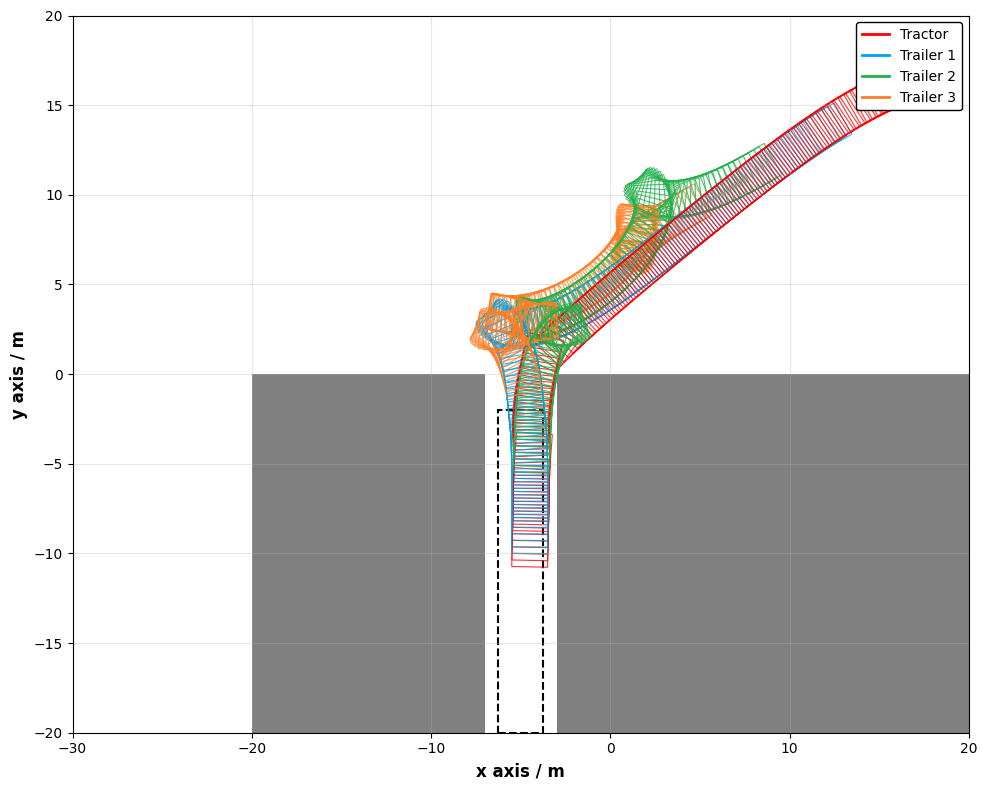

Generating progressive GIF animation (pcoc_animation.gif)...


KeyboardInterrupt: 

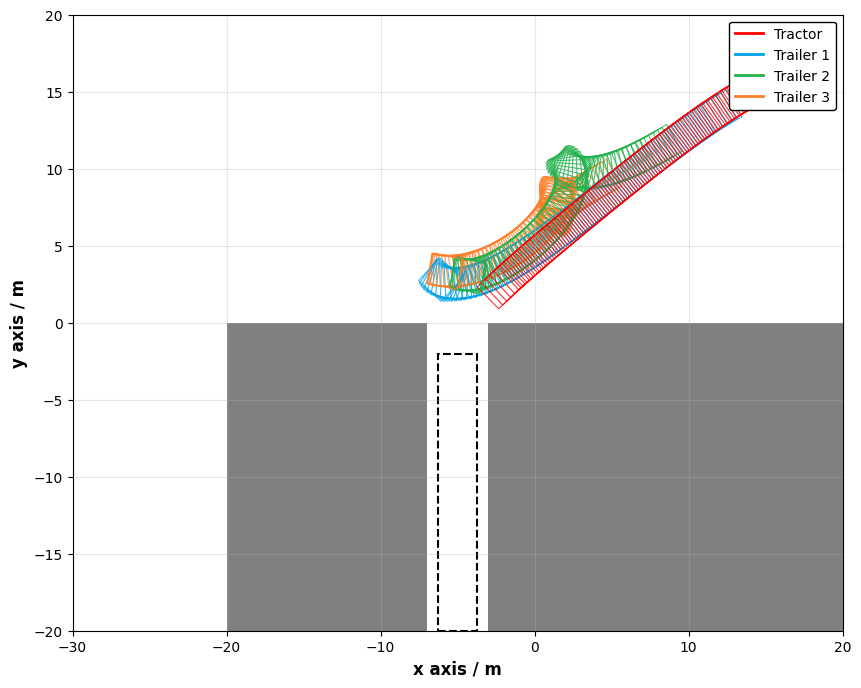

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

# ==============================================================================
# 12. DRAWING HELPERS (Unchanged)
# ==============================================================================
def get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo):
    """Calculates the 4 corners of the tractor and all 3 trailers for plotting."""
    polygons = []
    LHW = geo['LHW']
    
    # 1. Tractor
    L_front = geo['L_tractor_front_hang']
    L_wb = geo['L_tractor_wheelbase']
    L_rear = geo['L_tractor_rear_hang']
    front_ext = L_front + L_wb
    tractor = np.array([
        [x1 + front_ext*np.cos(th1) - LHW*np.sin(th1), y1 + front_ext*np.sin(th1) + LHW*np.cos(th1)],
        [x1 + front_ext*np.cos(th1) + LHW*np.sin(th1), y1 + front_ext*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) + LHW*np.sin(th1), y1 - L_rear*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) - LHW*np.sin(th1), y1 - L_rear*np.sin(th1) + LHW*np.cos(th1)]
    ])
    polygons.append(tractor)
    
    # 2. Trailers
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(x1, y1, th1, th2, th3, th4, geo)
    trailer_states = [(x2, y2, th2), (x3, y3, th3), (x4, y4, th4)]
    t_front, t_rear = geo['L_trailer_front_hang'], geo['L_trailer_rear_hang']
    
    for (tx, ty, t_th) in trailer_states:
        trailer = np.array([
            [tx + t_front*np.cos(t_th) - LHW*np.sin(t_th), ty + t_front*np.sin(t_th) + LHW*np.cos(t_th)],
            [tx + t_front*np.cos(t_th) + LHW*np.sin(t_th), ty + t_front*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) + LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) - LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) + LHW*np.cos(t_th)]
        ])
        polygons.append(trailer)
        
    return polygons

# ==============================================================================
# 13. GENERATING THE PAPER-STYLE VISUALS
# ==============================================================================
def setup_paper_figure(obstacles, bvc, scale):
    """Sets up the canvas, obstacles, and goal box exactly like Bai Li's paper."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(scale['xmin'], scale['xmax'])
    ax.set_ylim(scale['ymin'], scale['ymax'])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.set_xlabel('x axis / m', fontsize=12, fontweight='bold')
    ax.set_ylabel('y axis / m', fontsize=12, fontweight='bold')
    
    # 1. Draw Obstacles (Solid Gray, no edges)
    for obs in obstacles:
        poly = patches.Polygon(np.column_stack((obs['x'], obs['y'])), closed=True, facecolor='gray', edgecolor='none')
        ax.add_patch(poly)
        
    # 2. Draw Goal Region (Dashed Black Box)
    goal_box = patches.Rectangle(
        (bvc['xc_end'] - bvc['x_end_half_width'], bvc['yc_end'] - bvc['y_end_half_width']),
        bvc['x_end_half_width'] * 2, bvc['y_end_half_width'] * 2,
        linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'
    )
    ax.add_patch(goal_box)
    
    # 3. Setup Custom Legend
    colors = ['red', '#00A2E8', '#22B14C', '#FF7F27'] # Tractor (Red), T1 (Cyan), T2 (Green), T3 (Orange)
    labels = ['Tractor', 'Trailer 1', 'Trailer 2', 'Trailer 3']
    legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=labels[i]) for i in range(4)]
    
    ax.legend(handles=legend_elements, loc='upper right', framealpha=1, edgecolor='black')
    
    return fig, ax, colors

def plot_static_swept_volume(trajectory, obstacles, bvc, scale, geo):
    """Generates the static high-res image (Like Figure 5)."""
    print("Generating Static Swept Volume Plot...")
    fig, ax, colors = setup_paper_figure(obstacles, bvc, scale)
    
    N = len(trajectory['x'])
    
    # Draw transparent outlines for every single frame
    for frame in range(N):
        x1, y1 = trajectory['x'][frame], trajectory['y'][frame]
        th1, th2, th3, th4 = trajectory['th1'][frame], trajectory['th2'][frame], trajectory['th3'][frame], trajectory['th4'][frame]
        
        polys = get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo)
        
        for i, poly in enumerate(polys):
            # facecolor='none' creates the hollow "wireframe" look
            p = patches.Polygon(poly, closed=True, facecolor='none', edgecolor=colors[i], linewidth=0.8, alpha=0.8)
            ax.add_patch(p)
            
    plt.tight_layout()
    plt.savefig("pcoc_figure_5.png", dpi=300) # Saves high-res image
    plt.show()

def create_swept_volume_gif(trajectory, obstacles, bvc, scale, geo, filename="pcoc_animation.gif"):
    """Generates an animated GIF that progressively draws the swept volume."""
    print(f"Generating progressive GIF animation ({filename})...")
    fig, ax, colors = setup_paper_figure(obstacles, bvc, scale)
    
    N = len(trajectory['x'])
    
    # Pre-calculate all patches, but start them invisible (alpha=0)
    all_frame_patches = []
    for frame in range(N):
        x1, y1 = trajectory['x'][frame], trajectory['y'][frame]
        th1, th2, th3, th4 = trajectory['th1'][frame], trajectory['th2'][frame], trajectory['th3'][frame], trajectory['th4'][frame]
        
        polys = get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo)
        frame_patches = []
        for i, poly in enumerate(polys):
            p = patches.Polygon(poly, closed=True, facecolor='none', edgecolor=colors[i], linewidth=0.8, alpha=0.0)
            ax.add_patch(p)
            frame_patches.append(p)
        all_frame_patches.append(frame_patches)

    # Animation function: Make the current frame's patches visible
    def update(frame):
        for p in all_frame_patches[frame]:
            p.set_alpha(0.8) # Reveal the outline
        
        # We must return all modified artists in a flat list
        return [p for frame_list in all_frame_patches[:frame+1] for p in frame_list]

    # Compile Animation
    anim = FuncAnimation(fig, update, frames=N, interval=50, blit=True)
    
    # Save as an actual .gif file using Pillow
    writer = PillowWriter(fps=20)
    anim.save(filename, writer=writer)
    print(f"GIF saved successfully as {filename}!")
    
    plt.close()
    
    # If running in Jupyter, this will display the progressive animation inline
    return HTML(anim.to_jshtml())

# --- RUN VISUALIZATIONS ---

# 1. Show the static paper-quality plot (Saves as pcoc_figure_5.png)
plot_static_swept_volume(FINAL_TRAJECTORY, BASE_OBSTACLES, BVC, SCALE, GEO)

# 2. Generate and save the progressive GIF (Saves as pcoc_animation.gif)
display(create_swept_volume_gif(FINAL_TRAJECTORY, BASE_OBSTACLES, BVC, SCALE, GEO))